# CFPB Consumer Complaint Database — 数据质量检查

## tl;dr

本 notebook 对一个有界、可复现的 CFPB API 样本执行字段、主键、缺失、日期、枚举与覆盖检查。结论只用于判断数据是否适合进入本地 DuckDB / SQL Agent 原型，不用于推断全体消费者体验或给公司排名。

## Context & Methods

### Key Assumptions

- 一行代表一条已公开投诉，候选主键为 `complaint_id`。
- API 样本按月等额、月内按 `created_date_desc` 截取，属于工程验证样本而非概率随机样本。
- CFPB 官方说明该数据库不是消费者经历的统计代表性样本；公司投诉量必须结合公司规模或市场份额解释。
- 来源回执：`../data/raw/cfpb_source_receipt.json`。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = ROOT / "data" / "processed" / "cfpb_complaints_sample.parquet"
RECEIPT_PATH = ROOT / "data" / "raw" / "cfpb_source_receipt.json"

df = pd.read_parquet(DATA_PATH)
receipt = json.loads(RECEIPT_PATH.read_text(encoding="utf-8"))
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")
print("API last_updated:", receipt["api_meta"].get("last_updated"))
print("API stale/data issue:", receipt["api_meta"].get("is_data_stale"), receipt["api_meta"].get("has_data_issue"))

Loaded 1,000 rows × 15 columns
API last_updated: 2026-09-18T12:00:00-05:00
API stale/data issue: False False


## Data

### 1. 字段与样例

In [2]:
display(pd.DataFrame({"column": df.columns, "dtype": [str(df[c].dtype) for c in df.columns]}))
display(df.head(5))

,column,dtype
0,product,str
1,date_sent_to_company,"datetime64[us, UTC]"
2,issue,str
3,sub_product,str
4,zip_code,str
5,tags,str
6,complaint_id,string
7,timely,str
8,company_response,str
9,submitted_via,str


,product,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Credit reporting or other personal consumer reports,2025-02-01 00:00:24+00:00,Incorrect information on your report,Credit reporting,91040,NaN,11869104,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2025-01-31 23:59:53+00:00,CA,Company has responded to the consumer and the CFPB and chooses not to provid...,Information belongs to someone else
1,Credit reporting or other personal consumer reports,2025-02-01 00:05:01+00:00,Incorrect information on your report,Credit reporting,32244,NaN,11869688,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2025-01-31 23:59:47+00:00,FL,NaN,Account information incorrect
2,Credit reporting or other personal consumer reports,2025-02-01 00:02:26+00:00,Incorrect information on your report,Credit reporting,90017,NaN,11869102,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2025-01-31 23:59:39+00:00,CA,Company has responded to the consumer and the CFPB and chooses not to provid...,Information belongs to someone else
3,Credit reporting or other personal consumer reports,2025-02-01 00:08:34+00:00,Problem with a company's investigation into an existing problem,Credit reporting,30213,NaN,11869570,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2025-01-31 23:59:34+00:00,GA,Company has responded to the consumer and the CFPB and chooses not to provid...,Investigation took more than 30 days
4,Credit reporting or other personal consumer reports,2025-02-01 00:03:45+00:00,Problem with a company's investigation into an existing problem,Credit reporting,33463,NaN,11869520,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2025-01-31 23:59:32+00:00,FL,NaN,Their investigation did not fix an error on your report


### 2. 主键、重复与缺失

In [3]:
key_checks = pd.Series({
    "rows": len(df),
    "distinct_complaint_id": df["complaint_id"].nunique(dropna=True),
    "missing_complaint_id": df["complaint_id"].isna().sum(),
    "duplicate_complaint_id_rows": df["complaint_id"].duplicated(keep=False).sum(),
    "exact_duplicate_rows": df.duplicated().sum(),
})
display(key_checks.to_frame("value"))

nulls = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_rate_pct": (df.isna().mean() * 100).round(2),
    "distinct_non_null": df.nunique(dropna=True),
}).sort_values("null_rate_pct", ascending=False)
display(nulls)

,value
rows,1000
distinct_complaint_id,1000
missing_complaint_id,0
duplicate_complaint_id_rows,0
exact_duplicate_rows,0


,null_count,null_rate_pct,distinct_non_null
tags,973,97.3,2
company_public_response,465,46.5,3
sub_issue,23,2.3,57
product,0,0.0,11
date_sent_to_company,0,0.0,918
issue,0,0.0,40
sub_product,0,0.0,27
zip_code,0,0.0,667
complaint_id,0,0.0,1000
timely,0,0.0,2


## Results

### 3. 日期范围和发送时效

In [4]:
received = pd.to_datetime(df["date_received"], utc=True, errors="coerce")
sent = pd.to_datetime(df["date_sent_to_company"], utc=True, errors="coerce")
lag_days = (sent - received).dt.total_seconds() / 86400

date_checks = pd.Series({
    "date_received_min": received.min(),
    "date_received_max": received.max(),
    "invalid_date_received": received.isna().sum(),
    "invalid_date_sent": sent.isna().sum(),
    "negative_send_lag_rows": (lag_days < 0).sum(),
    "send_lag_over_15_days_rows": (lag_days > 15).sum(),
    "send_lag_over_30_days_rows": (lag_days > 30).sum(),
    "send_lag_median_days": lag_days.median(),
    "send_lag_p95_days": lag_days.quantile(0.95),
    "send_lag_max_days": lag_days.max(),
})
display(date_checks.to_frame("value"))

,value
date_received_min,2025-01-31 23:55:35+00:00
date_received_max,2026-08-31 23:59:58+00:00
invalid_date_received,0
invalid_date_sent,0
negative_send_lag_rows,0
send_lag_over_15_days_rows,9
send_lag_over_30_days_rows,6
send_lag_median_days,0.002384
send_lag_p95_days,0.024678
send_lag_max_days,99.840301


### 4. 样本覆盖（不是总体分布估计）

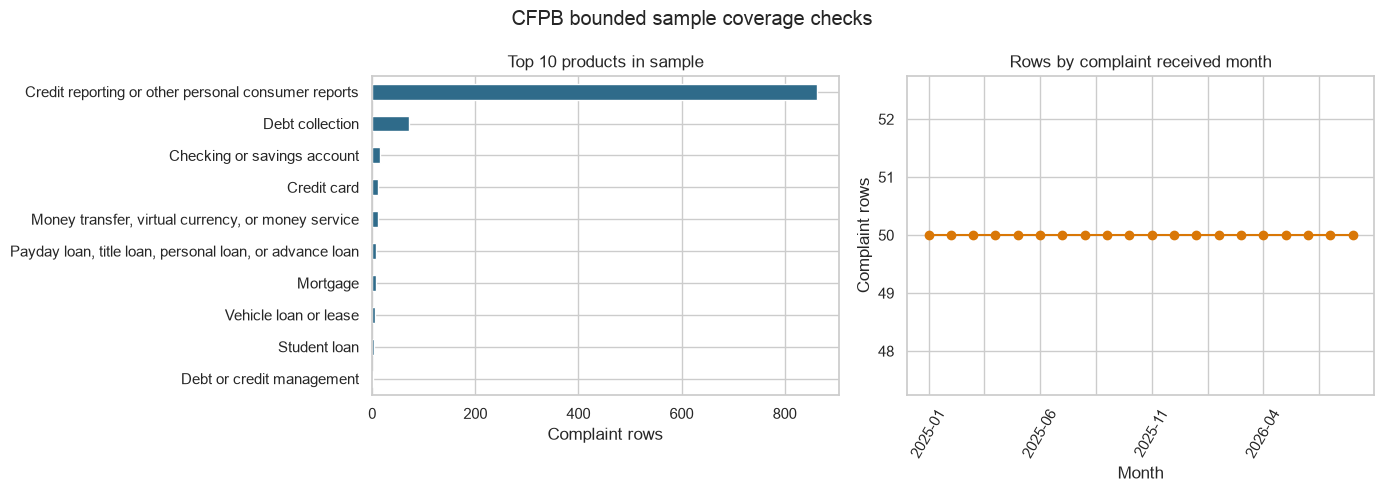

In [5]:
monthly = received.dt.tz_convert(None).dt.to_period("M").astype("string").value_counts().sort_index()
top_products = df["product"].fillna("<MISSING>").value_counts().head(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_products.plot.barh(ax=axes[0], color="#2F6B8A")
axes[0].set(title="Top 10 products in sample", xlabel="Complaint rows", ylabel="")
monthly.plot(ax=axes[1], marker="o", color="#D97706")
axes[1].set(title="Rows by complaint received month", xlabel="Month", ylabel="Complaint rows")
axes[1].tick_params(axis="x", rotation=60)
fig.suptitle("CFPB bounded sample coverage checks")
plt.tight_layout()
plt.show()

### 5. 枚举和格式

In [6]:
timely_values = df["timely"].fillna("<MISSING>").value_counts(dropna=False)
state_valid = df["state"].isna() | df["state"].astype(str).str.fullmatch(r"[A-Z]{2}")
zip_text = df["zip_code"].astype("string")
privacy_masked_zip = zip_text.str.fullmatch(r"(?:[0-9]{3}XX|XXXXX)", na=False)
zip_valid = (
    df["zip_code"].isna()
    | zip_text.str.fullmatch(r"[0-9]{3}(?:[0-9]{2})?", na=False)
    | privacy_masked_zip
)

display(timely_values.to_frame("rows"))
display(pd.Series({
    "invalid_state_format_rows": (~state_valid).sum(),
    "privacy_masked_zip_rows": privacy_masked_zip.sum(),
    "invalid_zip_format_rows": (~zip_valid).sum(),
}).to_frame("value"))

,rows
timely,
Yes,995
No,5


,value
invalid_state_format_rows,0
privacy_masked_zip_rows,35
invalid_zip_format_rows,0


## Takeaways

- 主键、重复、日期与字段结构的实际结果见上方已执行输出。
- 结构化字段足以支持 DuckDB 指标查询、产品/问题/渠道拆解和响应时效分析。
- 当前官方 API 不含投诉叙述文本，不能凭空宣称完成 narrative RAG。
- 高缺失字段需要按业务定义解释；可选公开回应、标签、子产品和子问题的空值不应自动当作数据错误。
- 此样本按月等额、月内按创建时间降序截取，只适合工程验证；公司比较需要公司规模/市场份额等外部分母。